# Jordan Bell's Notebook

## Goal
- To analyze and compare the writing styles of two authors across their books in two shared genres, looking for patterns that distinguish them from each other and patterns associated with genre.

## Methods
- Find two authors with multiple books in the same two genres using Gutenberg's book search
    - Arthur Conan Doyle:
        - [The Lost World, Science Fiction](https://www.gutenberg.org/cache/epub/139/pg139-images.html)
        - [The Posion Belt, Science Fiction](https://www.gutenberg.org/cache/epub/126/pg126-images.html)
        - [The Sign of the Four, Adventure](https://www.gutenberg.org/cache/epub/2097/pg2097-images.html)
        - [The White Company, Adventure](https://www.gutenberg.org/cache/epub/903/pg903-images.html)
    - Jack London:
        - [The Jacket, Science Fiction](https://www.gutenberg.org/cache/epub/1162/pg1162-images.html)
        - [The Iron Heel, Science Fiction](https://www.gutenberg.org/cache/epub/1164/pg1164-images.html)
        - [The Call of the Wild, Adventure](https://www.gutenberg.org/cache/epub/215/pg215-images.html)
        - [The Sea-Wolf, Adventure](https://www.gutenberg.org/cache/epub/1074/pg1074-images.html)
- Measure various writing characteristics of each book
- Discover distinctive words and phrases used by the authors
- Determine the similarities between books
- Find the biggest measurable differences between authors


## Part 1: Defining Metadata

Create data that specifies the authors, books, genres, and Project Gutenberg URLs that will be analyzed.

In [114]:
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


METADATA = {
    "Arthur Conan Doyle": [
        (
            "The Lost World",
            "Science Fiction",
            "https://www.gutenberg.org/cache/epub/139/pg139-images.html",
        ),
        (
            "The Poison Belt",
            "Science Fiction",
            "https://www.gutenberg.org/cache/epub/126/pg126-images.html",
        ),
        (
            "The Sign of the Four",
            "Adventure",
            "https://www.gutenberg.org/cache/epub/2097/pg2097-images.html",
        ),
        (
            "The White Company",
            "Adventure",
            "https://www.gutenberg.org/cache/epub/903/pg903-images.html",
        ),
    ],
    "Jack London": [
        (
            "The Jacket",
            "Science Fiction",
            "https://www.gutenberg.org/cache/epub/1162/pg1162-images.html",
        ),
        (
            "The Iron Heel",
            "Science Fiction",
            "https://www.gutenberg.org/cache/epub/1164/pg1164-images.html",
        ),
        (
            "The Call of the Wild",
            "Adventure",
            "https://www.gutenberg.org/cache/epub/215/pg215-images.html",
        ),
        (
            "The Sea-Wolf",
            "Adventure",
            "https://www.gutenberg.org/cache/epub/1074/pg1074-images.html",
        ),
    ],
}

print(f"Loaded metadata for {sum(len(v) for v in METADATA.values())} books.")
print(f"Authors: {', '.join(METADATA.keys())}")

for author, books in METADATA.items():
    print(f"  {author}: {len(books)} books")

Loaded metadata for 8 books.
Authors: Arthur Conan Doyle, Jack London
  Arthur Conan Doyle: 4 books
  Jack London: 4 books


In [115]:
def download_book(url):
    response = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=30
    )
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    for tag in soup(["script", "style", "nav", "header", "footer"]):
        tag.decompose()

    return soup.get_text(" ", strip=True)


def clean_text(text):
    text = re.sub(r"\s+", " ", text)

    start = re.search(
        r"\*\*\* START OF (?:THE|THIS) PROJECT GUTENBERG",
        text,
        re.IGNORECASE
    )

    end = re.search(
        r"\*\*\* END OF (?:THE|THIS) PROJECT GUTENBERG",
        text,
        re.IGNORECASE
    )

    if start:
        text = text[start.end():]

    if end:
        text = text[:end.start()]

    return text.strip()


books = []

for author, entries in METADATA.items():
    for title, genre, url in entries:
        print(f"Downloading: {title}...", end=" ")

        try:
            text = clean_text(download_book(url))

            books.append({
                "author": author,
                "title": title,
                "genre": genre,
                "url": url,
                "text": text
            })

            print(f"✓ {len(text):,} characters")

        except Exception as e:
            print(f"✗ FAILED: {e}")


df = pd.DataFrame(books)

print(f"\nSuccessfully loaded {len(df)} of 8 books.")

Downloading: The Lost World... ✓ 418,174 characters
Downloading: The Poison Belt... ✓ 162,268 characters
Downloading: The Sign of the Four... ✓ 231,213 characters
Downloading: The White Company... ✓ 809,001 characters
Downloading: The Jacket... ✓ 560,322 characters
Downloading: The Iron Heel... ✓ 497,857 characters
Downloading: The Call of the Wild... ✓ 175,260 characters
Downloading: The Sea-Wolf... ✓ 572,786 characters

Successfully loaded 8 of 8 books.


## Part 2: Writing Characteristics

Measures different characteristics of each book, including:
- Word count
- Average sentence length
- Vocabulary variety
- Percentage of dialogue
- Frequency of questions
- Frequency of exclamations

In [116]:
def words(text):
    return re.findall(
        r"\b[a-zA-Z]+(?:'[a-zA-Z]+)?\b",
        text.lower()
    )


def sentences(text):
    return [
        s.strip()
        for s in re.split(r"(?<=[.!?])\s+", text)
        if s.strip()
    ]


def dialogue_percentage(text):
    quoted = re.findall(r'["“](.*?)["”]', text, re.DOTALL)

    dialogue_words = sum(len(words(x)) for x in quoted)
    total_words = len(words(text))

    return 100 * dialogue_words / total_words


analysis = []

for _, row in df.iterrows():
    book_words = words(row["text"])
    book_sentences = sentences(row["text"])

    sentence_lengths = [
        len(words(s))
        for s in book_sentences
    ]

    unique_words = len(set(book_words))

    analysis.append({
        "Book": row["title"],
        "Author": row["author"],
        "Genre": row["genre"],
        "Words": len(book_words),
        "Avg. sentence": np.mean(sentence_lengths),
        "Unique words": unique_words,
        "Vocabulary variety %": unique_words / len(book_words) * 100,
        "Dialogue %": dialogue_percentage(row["text"]),
        "Questions / 1,000 words":
            row["text"].count("?") / len(book_words) * 1000,
        "Exclamations / 1,000 words":
            row["text"].count("!") / len(book_words) * 1000,
    })


analysis = pd.DataFrame(analysis)


display(
    analysis[
        [
            "Book",
            "Author",
            "Genre",
            "Words",
            "Avg. sentence",
            "Vocabulary variety %",
            "Dialogue %",
            "Questions / 1,000 words",
            "Exclamations / 1,000 words",
        ]
    ].round(1).set_axis(range(1, len(analysis) + 1))
)


,Book,Author,Genre,Words,Avg. sentence,Vocabulary variety %,Dialogue %,"Questions / 1,000 words","Exclamations / 1,000 words"
1,The Lost World,Arthur Conan Doyle,Science Fiction,76759,20.7,10.2,68.8,4.7,3.8
2,The Poison Belt,Arthur Conan Doyle,Science Fiction,29506,19.7,15.9,45.9,6.0,3.4
3,The Sign of the Four,Arthur Conan Doyle,Adventure,43865,17.9,12.2,68.7,4.9,2.9
4,The White Company,Arthur Conan Doyle,Adventure,152677,25.6,7.0,50.5,4.6,7.3
5,The Jacket,Jack London,Science Fiction,105883,17.0,9.3,15.0,2.7,1.5
6,The Iron Heel,Jack London,Science Fiction,89204,15.7,9.5,35.1,3.4,1.3
7,The Call of the Wild,Jack London,Adventure,32316,19.7,14.6,4.1,0.9,1.3
8,The Sea-Wolf,Jack London,Adventure,108098,17.5,8.2,24.5,5.0,2.9


## Part 3: Author Fingerprints

Identify unique words and phrases that are associated with each author.

In [117]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=2,
    max_df=0.90
)

X = vectorizer.fit_transform(df["text"])
terms = np.array(vectorizer.get_feature_names_out())


def distinctive_words(author, top_n=15):
    mask = (df["author"] == author).to_numpy()

    author_scores = np.asarray(
        X[mask].mean(axis=0)
    ).ravel()

    other_scores = np.asarray(
        X[~mask].mean(axis=0)
    ).ravel()

    difference = author_scores - other_scores

    top = difference.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "Word": terms[top],
        "Author association": difference[top]
    })


print("AUTHOR FINGERPRINTS: DISTINCTIVE WORDS")
print("=" * 80)

for author in df["author"].unique():
    print(f"\n{author}")
    print("-" * len(author))

    result = distinctive_words(author)

    print(", ".join(result["Word"].tolist()))

AUTHOR FINGERPRINTS: DISTINCTIVE WORDS

Arthur Conan Doyle
------------------
challenger, summerlee, sir, holmes, lord, john, round, professor, hath, treasure, knight, friend, window, sherlock, wooden

Jack London
-----------
buck, wolf, maud, warden, labor, pilate, jackson, jacket, class, bishop, ghost, deck, prison, till, heel


In [118]:
def ngrams(tokens, n):
    return zip(*[tokens[i:] for i in range(n)])


def phrase_counts(text, n=3):
    token_list = words(text)

    return Counter(
        " ".join(group)
        for group in ngrams(token_list, n)
    )


author_text = (
    df.groupby("author")["text"]
    .apply(lambda x: " ".join(x))
)


print("AUTHOR FINGERPRINTS: DISTINCTIVE PHRASES")
print("=" * 80)

all_phrases = {}

for author in author_text.index:
    other_author = [
        a for a in author_text.index
        if a != author
    ][0]

    own_counts = phrase_counts(author_text[author])
    other_counts = phrase_counts(author_text[other_author])

    scored = []

    for phrase, count in own_counts.items():
        if count < 4:
            continue

        other_count = other_counts.get(phrase, 0)

        score = count / (other_count + 1)

        scored.append((phrase, count, other_count, score))

    scored.sort(key=lambda x: x[3], reverse=True)

    all_phrases[author] = scored[:10]

    print(f"\n{author}")
    print("-" * len(author))

    for phrase, own, other, score in scored[:10]:
        print(f"{phrase:<35} {own:>4} uses")

AUTHOR FINGERPRINTS: DISTINCTIVE PHRASES

Arthur Conan Doyle
------------------
said sir nigel                        64 uses
by my hilt                            57 uses
said lord john                        53 uses
my fair lord                          43 uses
men at arms                           41 uses
by st paul                            34 uses
lord john roxton                      30 uses
the ape men                           29 uses
sir nigel loring                      29 uses
by saint paul                         28 uses

Jack London
-----------
the iron heel                        106 uses
wolf larsen s                         74 uses
the united states                     72 uses
in the jacket                         62 uses
the lady om                           54 uses
of the iron                           47 uses
chong mong ju                         46 uses
mr van weyden                         41 uses
the working class                     40 uses
back and forth       

## Part 4: Book Comparisons

Determine how similar books are to one another and determine whether authorship or genre has a stronger influence on writing style.

In [119]:
# Rebuild book-level vectors so every book has its own representation.
book_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

book_matrix = book_vectorizer.fit_transform(df["text"])

similarity = cosine_similarity(book_matrix)

similarity_df = pd.DataFrame(
    similarity,
    index=df["title"],
    columns=df["title"]
)

print("BOOK SIMILARITY")
print("=" * 80)

display(similarity_df.round(2))

print(
    "\nSimilarity ranges from 0 to 1. "
    "Higher values mean the books use more similar patterns of words and phrases."
)

# Calculate the average similarity for pairs sharing author or genre.
same_author = []
same_genre = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):

        score = similarity[i, j]

        if df.iloc[i]["author"] == df.iloc[j]["author"]:
            same_author.append(score)

        if df.iloc[i]["genre"] == df.iloc[j]["genre"]:
            same_genre.append(score)


author_similarity = np.mean(same_author)
genre_similarity = np.mean(same_genre)

print(f"\nAverage similarity for books by the SAME AUTHOR: {author_similarity:.3f}")
print(f"Average similarity for books in the SAME GENRE:  {genre_similarity:.3f}")

if author_similarity > genre_similarity:
    print("\nResult: In this collection, authorship produces the stronger similarity.")
elif genre_similarity > author_similarity:
    print("\nResult: In this collection, genre produces the stronger similarity.")
else:
    print("\nResult: Author and genre produce the same average similarity.")

BOOK SIMILARITY


title,The Lost World,The Poison Belt,The Sign of the Four,The White Company,The Jacket,The Iron Heel,The Call of the Wild,The Sea-Wolf
title,,,,,,,,
The Lost World,1.00,0.82,0.49,0.50,0.47,0.44,0.22,0.43
The Poison Belt,0.82,1.00,0.41,0.42,0.37,0.36,0.16,0.34
The Sign of the Four,0.49,0.41,1.00,0.55,0.54,0.51,0.23,0.50
The White Company,0.50,0.42,0.55,1.00,0.53,0.46,0.24,0.48
The Jacket,0.47,0.37,0.54,0.53,1.00,0.61,0.31,0.59
The Iron Heel,0.44,0.36,0.51,0.46,0.61,1.00,0.26,0.50
The Call of the Wild,0.22,0.16,0.23,0.24,0.31,0.26,1.00,0.29
The Sea-Wolf,0.43,0.34,0.50,0.48,0.59,0.50,0.29,1.00



Similarity ranges from 0 to 1. Higher values mean the books use more similar patterns of words and phrases.

Average similarity for books by the SAME AUTHOR: 0.479
Average similarity for books in the SAME GENRE:  0.448

Result: In this collection, authorship produces the stronger similarity.


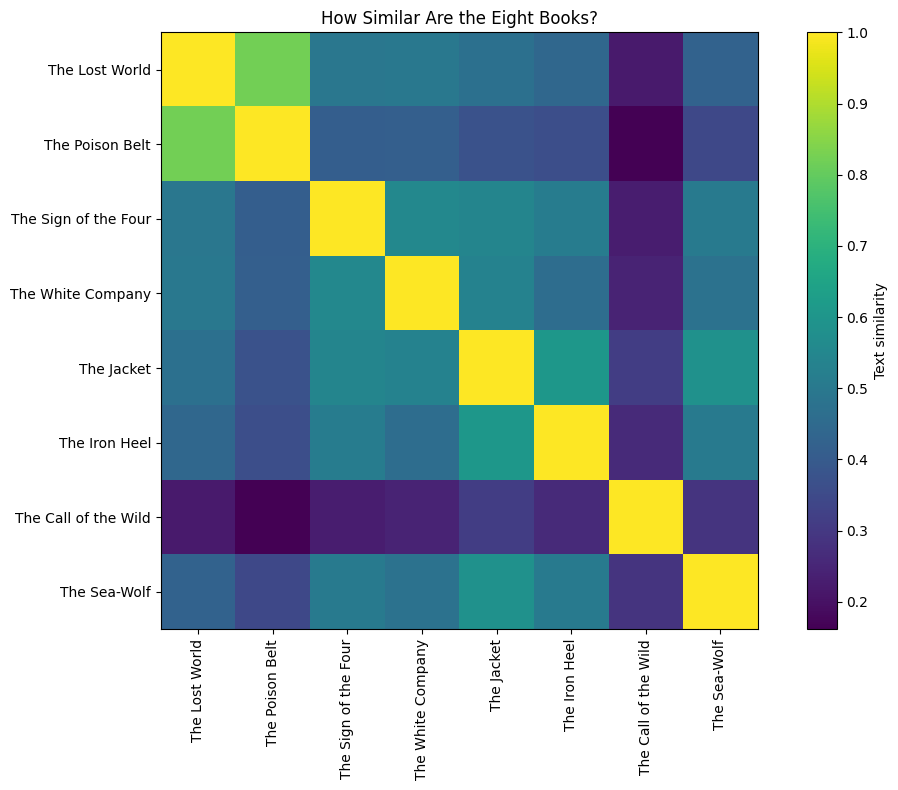

In [120]:
plt.figure(figsize=(11, 8))

plt.imshow(similarity, interpolation="nearest")

plt.xticks(
    range(len(df)),
    df["title"],
    rotation=90
)

plt.yticks(
    range(len(df)),
    df["title"]
)

plt.colorbar(label="Text similarity")

plt.title("How Similar Are the Eight Books?")
plt.tight_layout()
plt.show()


## Part 5: Biggest Differences

Directly compare both authors on the main writing characteristics and identify where their styles differ most.

In [121]:
comparison_features = [
    ("Avg. sentence", "average sentence length"),
    ("Vocabulary variety %", "vocabulary variety"),
    ("Dialogue %", "percentage of dialogue"),
    ("Questions / 1,000 words", "questions"),
    ("Exclamations / 1,000 words", "exclamations"),
]

print("BIGGEST DIFFERENCES")
print("=" * 80)

for column, label in comparison_features:

    author_values = analysis.groupby("Author")[column].mean()

    authors = list(author_values.index)

    a = author_values[authors[0]]
    b = author_values[authors[1]]

    difference = abs(a - b)
    midpoint = (a + b) / 2

    percent_difference = (
        difference / midpoint * 100
        if midpoint != 0 else 0
    )

    higher = authors[0] if a > b else authors[1]

    print(
        f"\n{label.title()}: "
        f"{higher} is {percent_difference:.1f}% higher "
        f"({max(a,b):.1f} vs {min(a,b):.1f})."
    )

BIGGEST DIFFERENCES

Average Sentence Length: Arthur Conan Doyle is 18.0% higher (21.0 vs 17.5).

Vocabulary Variety: Arthur Conan Doyle is 8.7% higher (11.3 vs 10.4).

Percentage Of Dialogue: Arthur Conan Doyle is 99.3% higher (58.5 vs 19.7).

Questions: Arthur Conan Doyle is 51.1% higher (5.0 vs 3.0).

Exclamations: Arthur Conan Doyle is 85.2% higher (4.3 vs 1.7).
